## Source data

In [4]:
import sys
import os

# changes root folder
sys.path.append(os.path.abspath(r'D:\mattf\My\Coding\Courses\Data Science\Github Projects\1\housing-price-pipeline'))

# import data
from src.data_loader import load_housing_data
df = load_housing_data(save_path='../data/raw/housing.csv')

## 1. Basic inspection

Results from the time of observation
- 20640 entries
- zero null values from isnull().sum()

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [3]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [4]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


## 2. Tartget distribution

Tartget column : MedHouseVal

From df.describe() for MedHouseVal :
- Min   = 0.149990
- Max   = 5.000010
- Mean  = 2.068558
- std   = 1.153956

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

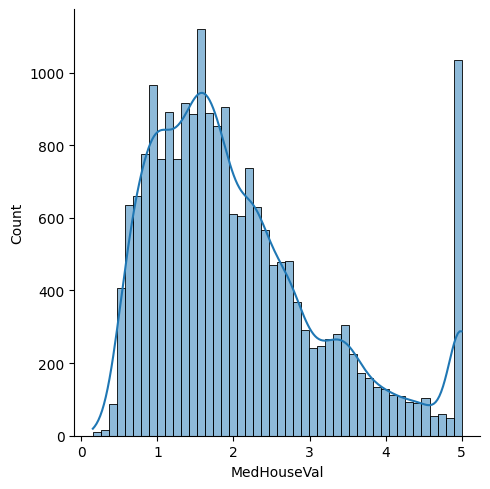

In [7]:
sns.displot(data=df['MedHouseVal'], kde=True)

## 3. Feature distribution

Note:
- The max cutoff for MedHouseVal appears to be set to 5 x 10^5, though the max value slightly exceeds this (Not significant, but can't be reasonably sure why without context)
- This artificial cap compresses all values of equal or greater value to appear visually the same on the graph
- The result of the above causes an usual looking stark uptick in count density that seems to defy the trend (this behavior can be seen in graphs such as Population vs MedHouseVal or AveBedrms vs HouseAge)

In [ ]:
sns.pairplot(df[['MedHouseVal', 'MedInc', 'AveRooms', 'HouseAge']])

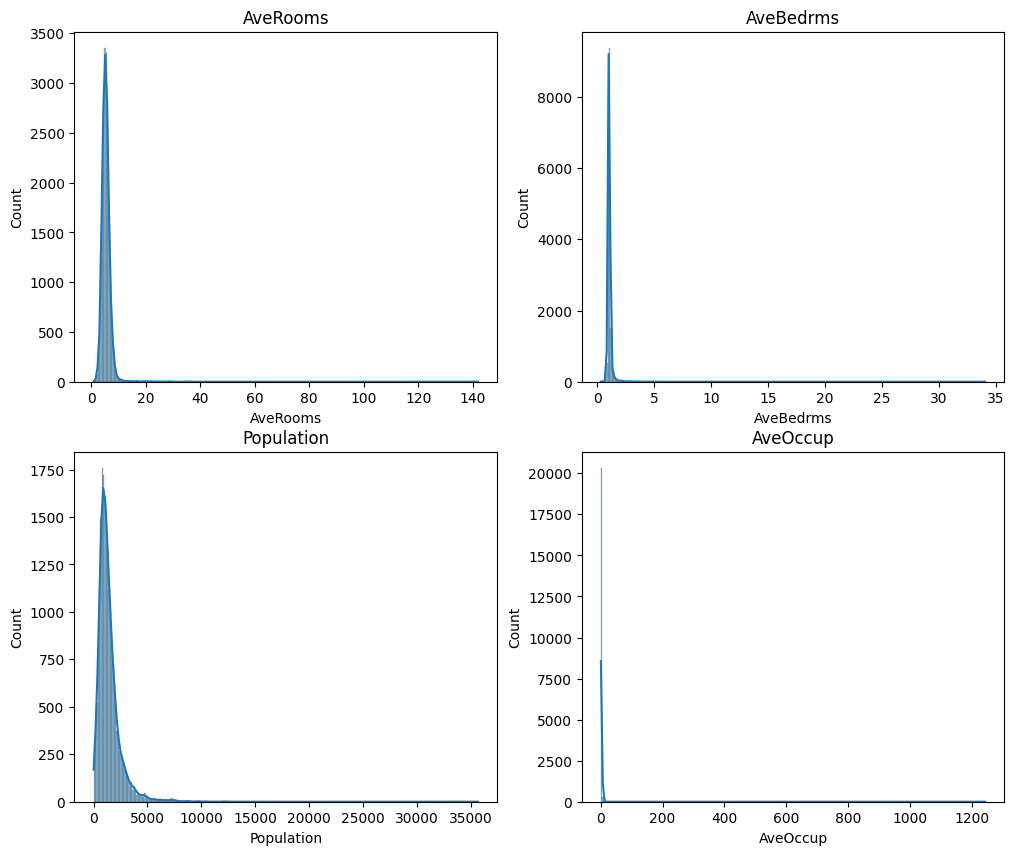

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for ax, col in zip(axes.flat, ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col)

## 4. Correlation heatmap

<Axes: >

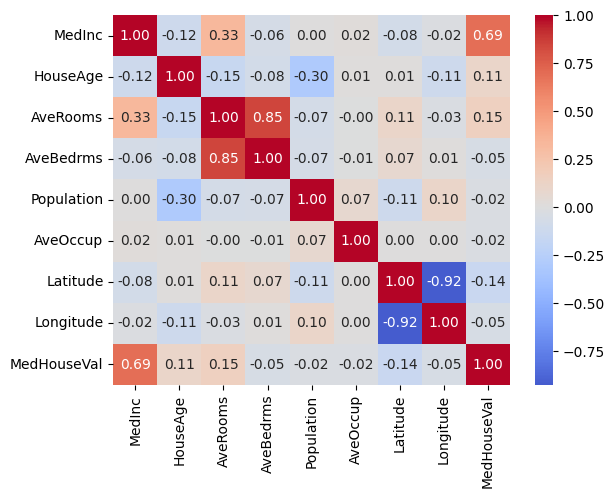

In [10]:
corr = df.corr()
sns.heatmap(data=corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)

## 5. Geographic scatter

<Axes: xlabel='Longitude', ylabel='Latitude'>

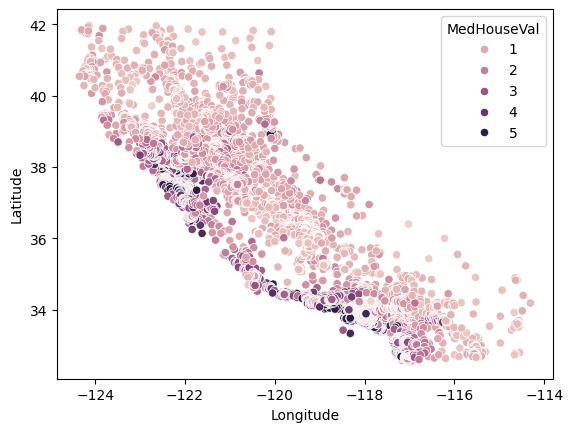

In [11]:
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='MedHouseVal')